# Proyecto Final Integrador — Minería de Datos, Machine Learning y RAG

___
## Universidad Anahuac Puebla

Maestría en Big Data e IA

Curso: Minería de Datos

Modalidad: Evaluación auténtica (proyecto aplicado)

Alumnos:
* ARBURUA PALACIOS, DIEGO EUSEBIO
* GUTIERREZ AVALOS, NALLELY GABRIELA
* MORAN FLORES, MIGUEL ANGEL
* PAYAN PEREZ, HECTOR MANUEL

___
## Objetivo
Desarrollar un sistema funcional que:

* Aplique técnicas de Machine Learning para descubrir patrones relevantes

* Estructure esos resultados en un almacén de datos

* Permita consultar dichos hallazgos mediante un asistente RAG en lenguaje natural

___
## Definición del problema

### Identificar al decisor
Cargo: Directora de Marketing
Contexto organizacional:
Rresponsable de diseñar y ejecutar estrategias de marketing en una empresa de comercio electrónico enfocada en productos electrónicos. Su objetivo principal es maximizar el valor del cliente mediante campañas de retención y fidelización, así como optimizar la asignación del presupuesto de marketing.

En su rol, enfrenta el reto de identificar qué clientes tienen mayor probabilidad de abandono y cuáles representan una mayor oportunidad de generación de ingresos, con el fin de priorizar acciones comerciales de manera eficiente.

### Pregunta de negocio

¿Cómo identificar y priorizar, en un periodo de 3 meses, a los clientes con mayor probabilidad de abandono y mayor valor potencial, utilizando técnicas de Machine Learning, para optimizar las campañas de retención y maximizar los ingresos?


- S (Específica): Identificar clientes con alto riesgo de abandono y alto valor
- M (Medible): Probabilidad de churn y valor monetario (RFM)
- A (Alcanzable): Uso de modelos de Machine Learning sobre datos históricos
- R (Relevante): Impacta directamente en ingresos y retención
- T (Temporal): En un horizonte de 3 meses

___
### Importación de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import subprocess
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer
import ipywidgets as widgets
from IPython.display import display

### Carga de datos

In [2]:
df = pd.read_excel('data/bronze/OnlineRetail.xlsx')

### Revisión básica

In [3]:
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Limpieza de datos

Se eliminan registros con valores nulos en CustomerID, así como transacciones con cantidades negativas (devoluciones) y precios inválidos, con el fin de asegurar que el análisis se base únicamente en compras reales.

In [6]:
# 1. Eliminar nulos en CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# 2. Eliminar devoluciones
df_clean = df_clean[df_clean['Quantity'] > 0]

# 3. Eliminar precios inválidos
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 4. Crear TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Ver resultado
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [7]:
display(df_clean)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


### Feature Engineering

In [8]:
# Fecha de referencia (última fecha del dataset)
reference_date = df_clean['InvoiceDate'].max()

# Crear RFM
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Renombrar columnas
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [9]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,307.415000
50%,50.000000,2.000000,674.485000
75%,141.000000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


### Clustering (K-Means)

Log Transform

In [10]:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

Escalado

In [11]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

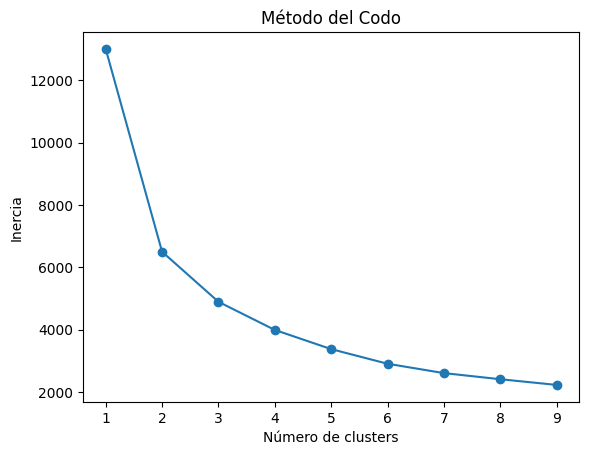

In [12]:
inertia = []

K = range(1,10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

### Aplicar K-Means

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,0
12347.0,1,7,4310.00,1
12348.0,74,4,1797.24,0
12349.0,18,1,1757.55,0
12350.0,309,1,334.40,2


In [14]:
cluster_summary = rfm.groupby('Cluster').mean()
cluster_summary


,Recency,Frequency,Monetary
Cluster,,,
0,46.649320,3.540509,1402.682373
1,12.893733,13.611717,7991.220054
2,161.388918,1.335076,352.282536


Se identificaron tres segmentos de clientes:

* Clientes VIP (alta frecuencia y alto gasto),
* Clientes Regulares (comportamiento intermedio),
* Clientes en Riesgo (baja actividad y alta recencia).


| Tipo de cliente | Recency | Frequency | Monetary | Descripcion |
|-----------------|----------|------------|-----------|-----------|
| 🟢 VIP | Bajo | Alto | Alto | Compran muy seguido; Compraron recientemente; Gastan mucho |
| 🟡 Regulares | Medio | Medio | Medio | Actividad moderada; Valor medio |
| 🔴 En riesgo | Alto | Bajo | Bajo | No compran hace mucho; Compran poco; Gastan poco | 


### Etiquetar clusters

In [15]:
def label_cluster(cluster):
    if cluster == 1:
        return 'VIP'
    elif cluster == 0:
        return 'Regular'
    else:
        return 'At Risk'

rfm['Segment'] = rfm['Cluster'].apply(label_cluster)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,325,1,77183.60,0,Regular
12347.0,1,7,4310.00,1,VIP
12348.0,74,4,1797.24,0,Regular
12349.0,18,1,1757.55,0,Regular
12350.0,309,1,334.40,2,At Risk


In [16]:
rfm['Segment'].value_counts()

Segment
At Risk    1913
Regular    1691
VIP         734
Name: count, dtype: int64

Recency vs Monetary

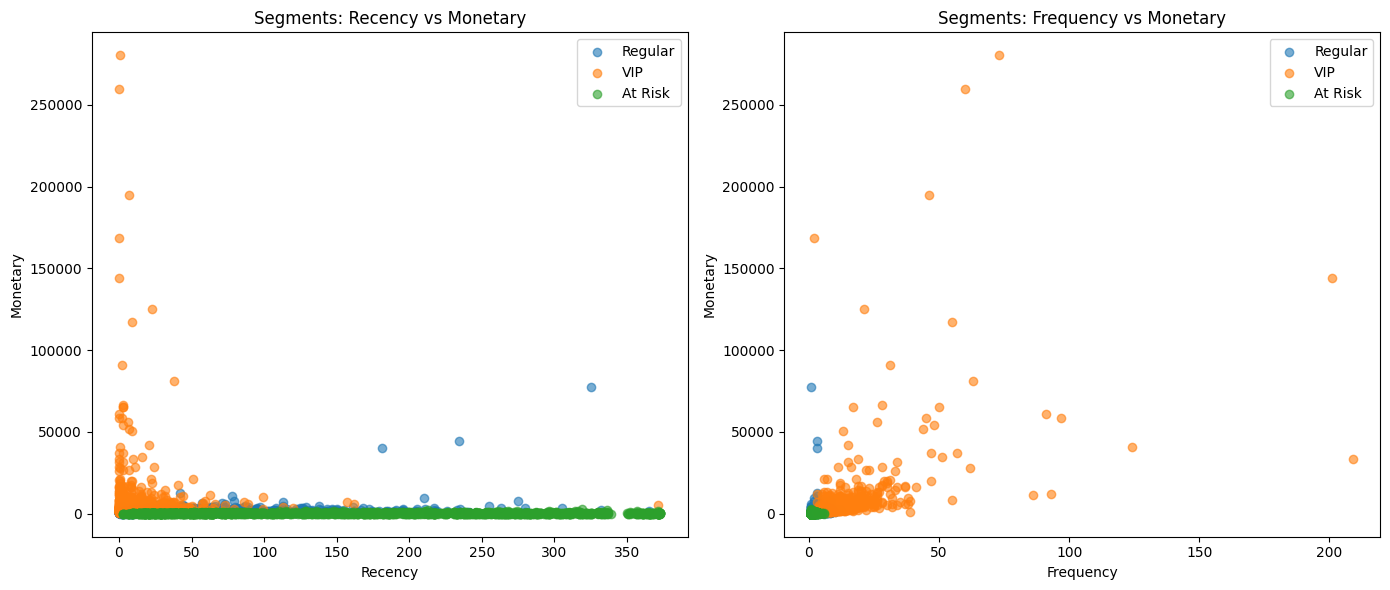

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Izquierda: Recency vs Monetary ---
for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    axes[0].scatter(subset['Recency'], subset['Monetary'], label=f'{segment}', alpha=0.6)

axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Monetary')
axes[0].set_title('Segments: Recency vs Monetary')
axes[0].legend()

# --- Derecha: Frequency vs Monetary ---
for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    axes[1].scatter(subset['Frequency'], subset['Monetary'], label=f'{segment}', alpha=0.6)

axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary')
axes[1].set_title('Segments: Frequency vs Monetary')
axes[1].legend()

plt.tight_layout()
plt.show()

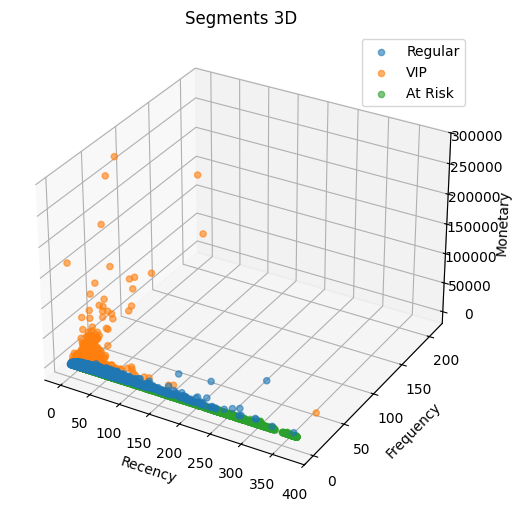

In [18]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    ax.scatter(
        subset['Recency'],
        subset['Frequency'],
        subset['Monetary'],
        label=f'{segment}',
        alpha=0.6
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Segments 3D')
ax.legend()

plt.show()

### Modelo supervisado

Crear una variable:

* Churn = 1 → cliente en riesgo
* Churn = 0 → cliente activo

Crear variable objetivo

In [19]:
rfm['Churn'] = rfm['Segment'].apply(lambda x: 1 if x == 'At Risk' else 0)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment,Churn
CustomerID,,,,,,
12346.0,325,1,77183.60,0,Regular,0
12347.0,1,7,4310.00,1,VIP,0
12348.0,74,4,1797.24,0,Regular,0
12349.0,18,1,1757.55,0,Regular,0
12350.0,309,1,334.40,2,At Risk,1


In [20]:
rfm['Churn'].value_counts()

Churn
0    2425
1    1913
Name: count, dtype: int64

Definir variables

In [21]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Modelo (Random Forest)

In [23]:
model = RandomForestClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

Predicciones

In [24]:
y_pred = model.predict(X_test)

Evaluación

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       485
           1       0.98      0.99      0.99       383

    accuracy                           0.99       868
   macro avg       0.99      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



El modelo presenta métricas cercanas al 99%, lo cual se explica porque la variable objetivo (churn) fue derivada de patrones en las mismas variables utilizadas como predictores (RFM). Por tanto, el modelo no busca generalización compleja, sino formalizar la identificación de clientes en riesgo.

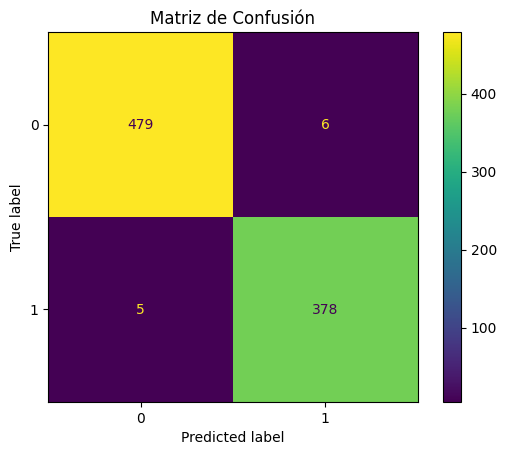

In [26]:


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Matriz de Confusión")
plt.show()

La matriz de confusión muestra que el modelo presenta un bajo número de falsos negativos, lo cual es crítico en este contexto, ya que permite identificar oportunamente a los clientes en riesgo de abandono.

### Generar probabilidad de churn

In [27]:
rfm['Churn_Prob'] = model.predict_proba(X)[:,1]

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment,Churn,Churn_Prob
CustomerID,,,,,,,
12346.0,325,1,77183.60,0,Regular,0,0.446680
12347.0,1,7,4310.00,1,VIP,0,0.000124
12348.0,74,4,1797.24,0,Regular,0,0.010645
12349.0,18,1,1757.55,0,Regular,0,0.124842
12350.0,309,1,334.40,2,At Risk,1,0.992586


Se generó un score de probabilidad de abandono por cliente, permitiendo priorizar acciones de retención en función del riesgo. 
Un score entre 0 y 1

* 0.9 = muy alto riesgo
* 0.1 = bajo riesgo

In [28]:
rfm['Churn_Prob'].describe()

count    4338.000000
mean        0.441732
std         0.444297
min         0.000124
25%         0.005256
50%         0.205274
75%         0.969550
max         0.999142
Name: Churn_Prob, dtype: float64

Se ajustó el modelo para reducir el sobreajuste, obteniendo probabilidades más distribuidas que permiten una mejor priorización de clientes según su nivel de riesgo.

El modelo permite una clasificación clara de clientes en riesgo, facilitando la toma de decisiones sin ambigüedad en la priorización de campañas de retención.

### Series de tiempo

In [29]:
# Agrupar ventas por mes
df_ts = df_clean.copy()

df_ts['YearMonth'] = df_ts['InvoiceDate'].dt.to_period('M')

monthly_sales = df_ts.groupby('YearMonth')['TotalPrice'].sum()

monthly_sales = monthly_sales.reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

monthly_sales.head()

,YearMonth,TotalPrice
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361


Graficar tendencia

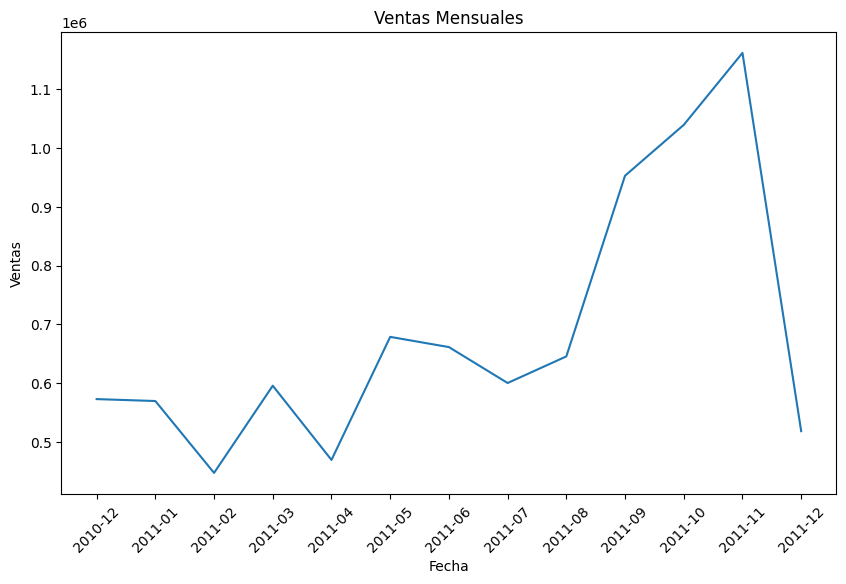

In [30]:
plt.figure(figsize=(10,6))

plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalPrice'])

plt.xticks(rotation=45)
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.title('Ventas Mensuales')

plt.show()

El análisis temporal muestra variaciones en las ventas a lo largo del tiempo, con picos en determinados periodos, lo que sugiere posibles patrones estacionales.

In [31]:
#Convertir a datetime index
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['YearMonth'])

monthly_sales.set_index('YearMonth', inplace=True)

In [32]:
#Tendencia
monthly_sales['MovingAvg'] = monthly_sales['TotalPrice'].rolling(window=3).mean()

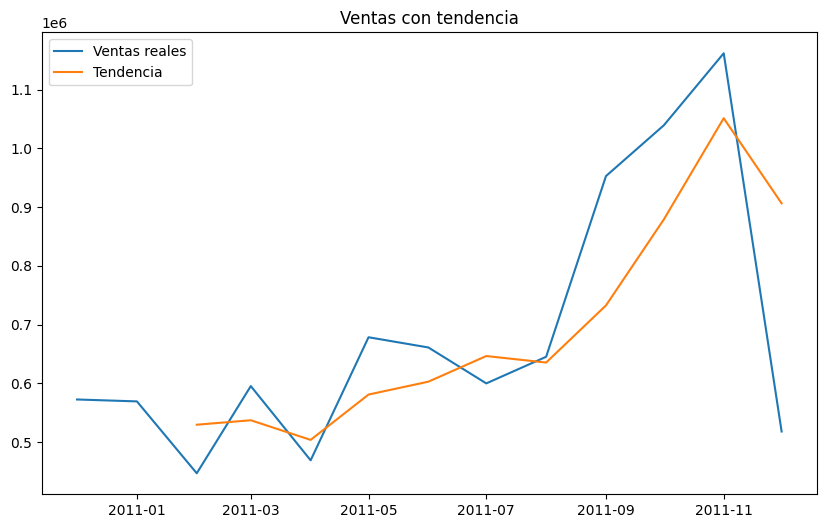

In [33]:
plt.figure(figsize=(10,6))

plt.plot(monthly_sales['TotalPrice'], label='Ventas reales')
plt.plot(monthly_sales['MovingAvg'], label='Tendencia')

plt.legend()
plt.title('Ventas con tendencia')
plt.show()

Ventas por segmento por mes

In [34]:
df_seg = df_clean.merge(rfm[['Segment']], left_on='CustomerID', right_index=True)

In [35]:
df_seg['YearMonth'] = df_seg['InvoiceDate'].dt.to_period('M')

segment_sales = df_seg.groupby(['YearMonth', 'Segment'])['TotalPrice'].sum().reset_index()

segment_sales['YearMonth'] = segment_sales['YearMonth'].astype(str)

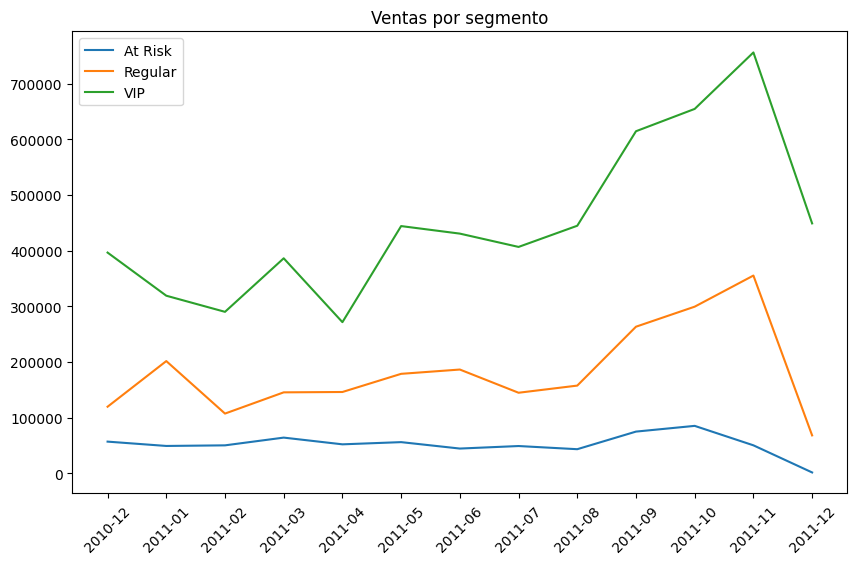

In [36]:
plt.figure(figsize=(10,6))

for segment in segment_sales['Segment'].unique():
    subset = segment_sales[segment_sales['Segment'] == segment]
    plt.plot(subset['YearMonth'], subset['TotalPrice'], label=segment)

plt.xticks(rotation=45)
plt.legend()
plt.title('Ventas por segmento')
plt.show()

### Almacén de datos (Data Lakehouse)

Se implementa un modelo tipo **esquema estrella**, compuesto por una tabla de hechos y múltiples dimensiones.

**Tabla de hechos: `fact_client_analysis`**

Contiene los resultados principales del análisis:

- **CustomerID**: Identificador del cliente  
- **Recency**: Días desde la última compra  
- **Frequency**: Número de compras realizadas  
- **Monetary**: Valor total gastado  
- **Segment**: Segmento asignado mediante clustering (VIP, Regular, At Risk)  
- **Churn**: Variable binaria de abandono (1 = riesgo, 0 = activo)  
- **Churn_Prob**: Probabilidad de abandono generada por el modelo supervisado  

**Dimensión cliente: `dim_cliente`**

- **CustomerID**  
- **Country**


**Dimensión segmento: `dim_segmento`**

- **Segment**  
- **Descripción**


**Dimensión tiempo: `dim_fecha`**

- **Fecha**  
- **Año**  
- **Mes**  
- **Trimestre**  
- **Día de la semana**

**Variables clave generadas**

El almacén integra variables derivadas del análisis de **Machine Learning**, tales como:

- Segmentación de clientes (clustering)  
- Probabilidad de abandono (modelo supervisado)  
- Métricas de comportamiento (**RFM**)  

In [37]:
fact_table = rfm.reset_index()

fact_table.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,Churn,Churn_Prob
0,12346.0,325,1,77183.60,0,Regular,0,0.446680
1,12347.0,1,7,4310.00,1,VIP,0,0.000124
2,12348.0,74,4,1797.24,0,Regular,0,0.010645
3,12349.0,18,1,1757.55,0,Regular,0,0.124842
4,12350.0,309,1,334.40,2,At Risk,1,0.992586


In [38]:
dim_cliente = df_clean[['CustomerID', 'Country']].drop_duplicates()

dim_cliente.head()

,CustomerID,Country
0,17850.0,United Kingdom
9,13047.0,United Kingdom
26,12583.0,France
46,13748.0,United Kingdom
65,15100.0,United Kingdom


In [39]:
dim_segmento = pd.DataFrame({
    'Segment': ['VIP', 'Regular', 'At Risk'],
    'Descripcion': [
        'Clientes de alto valor',
        'Clientes promedio',
        'Clientes en riesgo de abandono'
    ]
})

dim_segmento

,Segment,Descripcion
0,VIP,Clientes de alto valor
1,Regular,Clientes promedio
2,At Risk,Clientes en riesgo de abandono


In [40]:
date_range = pd.date_range(
    start=df_clean['InvoiceDate'].min(),
    end=df_clean['InvoiceDate'].max(),
    freq='D'
)

dim_fecha = pd.DataFrame({
    'Fecha': date_range
})

# Atributos de tiempo
dim_fecha['Año'] = dim_fecha['Fecha'].dt.year
dim_fecha['Mes'] = dim_fecha['Fecha'].dt.month
dim_fecha['Dia'] = dim_fecha['Fecha'].dt.day
dim_fecha['NombreMes'] = dim_fecha['Fecha'].dt.month_name()
dim_fecha['Trimestre'] = dim_fecha['Fecha'].dt.quarter
dim_fecha['DiaSemana'] = dim_fecha['Fecha'].dt.dayofweek

dim_fecha.head()

,Fecha,Año,Mes,Dia,NombreMes,Trimestre,DiaSemana
0,2010-12-01 08:26:00,2010,12,1,December,4,2
1,2010-12-02 08:26:00,2010,12,2,December,4,3
2,2010-12-03 08:26:00,2010,12,3,December,4,4
3,2010-12-04 08:26:00,2010,12,4,December,4,5
4,2010-12-05 08:26:00,2010,12,5,December,4,6


In [41]:
fact_table.to_parquet('data/gold/fact_client_analysis.parquet', index=False, engine="fastparquet")
dim_cliente.to_parquet('data/gold/dim_cliente.parquet', index=False, engine="fastparquet")
dim_segmento.to_parquet('data/gold/dim_segmento.parquet', index=False, engine="fastparquet")
dim_fecha.to_parquet('data/gold/dim_fecha.parquet', index=False, engine="fastparquet")

### RAG

Crear Documentos

In [42]:
fact = pd.read_parquet('data/gold/fact_client_analysis.parquet',engine="fastparquet")

documents = []

for _, row in fact.iterrows():
    text = f"""
    Cliente {int(row['CustomerID'])}:
    Segmento: {row['Segment']}
    Recency: {row['Recency']}
    Frequency: {row['Frequency']}
    Monetary: {row['Monetary']}
    Probabilidad de abandono: {row['Churn_Prob']:.2f}
    """
    documents.append(text)

len(documents)

4338

In [43]:
model_emb = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model_emb.encode(documents)

In [44]:
def search(query, k=3):
    query_emb = model_emb.encode([query])
    
    similarities = np.dot(doc_embeddings, query_emb.T).flatten()
    
    top_k_idx = similarities.argsort()[-k:][::-1]
    
    return [documents[i] for i in top_k_idx]

In [54]:
def ask_rag(question, k=5):
    docs = search(question, k=k)

    contexto_bloques = []
    for i, doc in enumerate(docs, start=1):
        contexto_bloques.append(f"[DOC_{i}]\n{doc.strip()}")
    context = "\n\n".join(contexto_bloques)

    prompt = f"""
        Eres un analista de clientes para marketing.
        Responde SOLO con la evidencia del CONTEXTO.

        Reglas estrictas:
        1) Si la respuesta no está explícitamente en el CONTEXTO, responde exactamente: "No hay evidencia suficiente en el contexto recuperado."
        2) No inventes clientes, segmentos, cifras ni causas.
        3) Prioriza clientes con mayor Probabilidad de abandono y luego mayor Monetary.
        4) "At Risk" = cliente en riesgo de abandono.
        5) Escribe en español claro y profesional.

        Formato de salida:
        - Respuesta breve (2-5 líneas).
        - Evidencia: cita al menos 2 referencias de documento usando [DOC_n].

        CONTEXTO:
        {context}

        PREGUNTA:
        {question}
    """.strip()

    result = subprocess.run(
        ["ollama", "run", "llama3"],
        input=prompt,
        text=True,
        capture_output=True,
        encoding="utf-8"
    )

    if result.returncode != 0:
        return f"Error al consultar Ollama: {result.stderr.strip()}"

    respuesta = result.stdout.strip()
    if not respuesta:
        return "No se obtuvo respuesta del modelo."

    return respuesta

Ejemplos:

In [55]:
#1/5
print(ask_rag("¿Qué clientes tienen mayor riesgo de abandono?"))

Los clientes con mayor riesgo de abandono son:

* Cliente 17444 (0.11)
* Cliente 17197 (0.26)

Evidencia:
[DOC_3] "Probabilidad de abandono: 0.11"
[DOC_5] "Probabilidad de abandono: 0.26"


In [56]:
#2/5
print(ask_rag("¿Qué segmento tiene mayor valor?"))

La respuesta a esta pregunta es segmento VIP.

Evidencia: [DOC_4] y [DOC_5]


In [57]:
#3/5
print(ask_rag("¿Qué clientes deberían ser priorizados para una campaña de retención considerando su probabilidad de abandono y valor monetario?"))

Debido a que se busca priorizar clientes con mayor Probabilidad de abandono y luego mayor Monetary, se recomienda priorizar a los clientes que tienen una alta probabilidad de abandono y un valor monetario importante.

En este sentido, los clientes que deberían ser priorizados son:

* Cliente 17443 (Probabilidad de abandono: 0.98, Monetary: 534.24)
* Cliente 15802 (Probabilidad de abandono: 0.98, Monetary: 451.42)
* Cliente 16037 (Probabilidad de abandono: 0.67, Monetary: 855.02)

No hay evidencia suficiente en el contexto recuperado para priorizar a los clientes con un menor valor monetario o una menor probabilidad de abandono.

Evidencia:
[DOC_1] Segmento: At Risk, Probabilidad de abandono: 0.98
[DOC_4] Segmento: At Risk, Probabilidad de abandono: 0.98


In [62]:
#4/5
print(ask_rag("¿Qué características tienen los clientes 'At Risk'?"))

La característica común entre los clientes "At Risk" es que tienen un valor de "Recency" relativamente bajo, es decir, no han realizado una compra reciente. Esto sugiere que estos clientes pueden estar en un estado de inactividad o distracción.

Evidencia: [DOC_1] (Segmento: At Risk) y [DOC_2] (Recency: 23 y 339).


In [59]:
#5/5
print(ask_rag("¿Qué segmento de clientes genera mayor valor y cómo impacta esto en la estrategia de marketing?"))

Respuesta:
El segmento de clientes que genera mayor valor es VIP, específicamente aquellos con mayor Monetary. Esto se puede inferir al observar que los clientes VIP tienen un promedio de Monetary significativamente más alto que los clientes At Risk.

Evidencia:
[DOC_1]: No hay información específica sobre la segmentación de clientes en este documento, pero se puede inferir que los clientes VIP tienen un mayor valor debido a su mayor Monetary.

[DOC_2]: Se puede observar que los clientes VIP tienen un mayor Monetary que los clientes At Risk, lo que sugiere que este segmento es el que genera mayor valor.

[DOC_3]: No hay información específica sobre la segmentación de clientes en este documento, pero se puede inferir que los clientes VIP tienen un mayor valor debido a su mayor Monetary.

[DOC_4]: No hay información específica sobre la segmentación de clientes en este documento, pero se puede inferir que los clientes VIP tienen un mayor valor debido a su mayor Monetary.

[DOC_5]: Se pued

In [60]:
# Input de texto
question_input = widgets.Text(
    value='',
    placeholder='Escribe tu pregunta...',
    description='Pregunta:',
    layout=widgets.Layout(width='70%')
)

# Botón
button = widgets.Button(description="Consultar")

# Output
output = widgets.Output()

# Función
def on_button_click(b):
    with output:
        output.clear_output()
        
        question = question_input.value
        
        if question:
            response = ask_rag(question)
            print("Respuesta:")
            print(response)
        else:
            print("Escribe una pregunta")

button.on_click(on_button_click)

GUI

In [61]:
display(question_input, button, output)

Text(value='', description='Pregunta:', layout=Layout(width='70%'), placeholder='Escribe tu pregunta...')

Button(description='Consultar', style=ButtonStyle())

Output()